# Part 2.B — Fine-tuning pretrained GPT2 and BERT

Part 2.A built a model from nothing and it topped out around 90 slot F1. Here I start from
models that already know English and just adapt them to ATIS, using the same two heads and
the same joint score so the numbers line up with Part 2.A.

I try two backbones because they are built differently and it should show:

| | What it is | Where the intent comes from |
|---|---|---|
| **GPT2** | decoder, attends left-to-right | the **last real token** — with causal attention nothing else has seen the full sentence |
| **BERT** | encoder, attends both ways | the **`[CLS]`** token, which is what BERT was pretrained to use as a sentence summary |

My guess going in is that BERT does better at slots. Tagging a word is easier when you can
look at what comes after it, and GPT2 structurally cannot.

## The annoying part: words vs sub-tokens

ATIS gives one slot tag per **word**, but both tokenizers chop words into pieces:

```
word    : washington                 ->  wash  ##ing  ##ton
tag     : B-fromloc.city_name        ->   ?      ?      ?
```

Now there are three tokens and one label, so they no longer line up. What I do (following
Chen et al., https://arxiv.org/abs/1902.10909) is give the label to the **first piece** of
each word and mark every other piece `-100`, which is the value `CrossEntropyLoss` skips.
At scoring time I read predictions back only at those first-piece positions, which gets me
one tag per original word again so `conll.evaluate` can be used exactly as in Part 2.A.

Same setup as before: three seeds, mean ± std, selection on dev joint score
$J = \tfrac12 F1 + \tfrac12 Acc$, test touched once at the end.

## 1. Setup

In [1]:
import os
import json
import math
import copy
import random
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
from torch.utils.data import DataLoader

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModel

%matplotlib inline
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 220)

from conll import evaluate

DEVICE = 'cuda:0' if torch.cuda.is_available() else 'cpu'

SEEDS        = [42, 43, 44]
SEED         = SEEDS[0]
IGNORE       = -100     # CrossEntropyLoss skips these positions
MAX_LEN      = 64
BATCH_SIZE   = 32
N_EPOCHS     = 15
PATIENCE     = 4
WEIGHT_DECAY = 0.01
CLIP         = 1.0
AMP          = torch.cuda.is_available()    # fp16 on the tensor cores

torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)

print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU   : {torch.cuda.get_device_name(0)}')
print(f'Mixed precision: {AMP}')

Device: cuda:0
GPU   : Tesla T4
Mixed precision: True


## 2. Data

Exactly the same split as Part 2.A — same seed, same stratification — so the two parts are
comparing models rather than comparing data.

In [2]:
def load_json(path):
    with open(path) as f:
        return json.load(f)


tmp_train = load_json('dataset/ATIS/train.json')
test_raw  = load_json('dataset/ATIS/test.json')

counts = Counter(x['intent'] for x in tmp_train)
single  = [x for x in tmp_train if counts[x['intent']] == 1]
multi   = [x for x in tmp_train if counts[x['intent']] > 1]

train_raw, dev_raw = train_test_split(
    multi, test_size=0.10, random_state=SEED, shuffle=True,
    stratify=[x['intent'] for x in multi])
train_raw += single

# label spaces come from train only; anything new later falls back to 'unk'
slot2id = {'pad': 0, 'unk': 1}
for s in sorted({s for x in train_raw for s in x['slots'].split()}):
    slot2id.setdefault(s, len(slot2id))
intent2id = {'unk': 0}
for v in sorted({x['intent'] for x in train_raw}):
    intent2id.setdefault(v, len(intent2id))
id2slot = {v: k for k, v in slot2id.items()}

table1 = pd.DataFrame([
    {'Split': 'Train', 'Utterances': len(train_raw), 'Purpose': 'Fine-tuning'},
    {'Split': 'Dev',   'Utterances': len(dev_raw),   'Purpose': 'Model selection'},
    {'Split': 'Test',  'Utterances': len(test_raw),  'Purpose': 'Final evaluation'},
])
display(table1)
print(f'Slot labels: {len(slot2id)} | Intent labels: {len(intent2id)}')

,Split,Utterances,Purpose
0,Train,4480,Fine-tuning
1,Dev,498,Model selection
2,Test,893,Final evaluation


Slot labels: 121 | Intent labels: 23


### Lining labels up with sub-tokens

This is the bit that actually needs care. `word_ids()` tells me, for every token the
tokenizer produced, which original word it came from. A token is the *first* piece of its
word when that number changes from the previous token. Those get the real label; the rest,
plus `[CLS]`/`[SEP]`/padding, get `-100`.

I also keep the list of first-piece positions, because at scoring time I need to pull
predictions out at exactly those spots to get back one tag per word.

Note GPT2 needs `add_prefix_space=True` to accept pre-split words at all, and has no
padding token of its own, so I reuse its EOS as padding.

In [3]:
class AtisSubword(data.Dataset):
    def __init__(self, rows, tokenizer):
        self.items = []
        for x in rows:
            words = x['utterance'].split()
            slots = x['slots'].split()
            enc = tokenizer(words, is_split_into_words=True,
                            truncation=True, max_length=MAX_LEN)
            word_ids = enc.word_ids()

            labels, first_pos, prev = [], [], None
            for pos, wid in enumerate(word_ids):
                if wid is None or wid == prev:      # special token, or a continuation
                    labels.append(IGNORE)
                else:
                    labels.append(slot2id.get(slots[wid], slot2id['unk']))
                    first_pos.append(pos)
                prev = wid

            n = len(first_pos)                      # words that survived truncation
            self.items.append({
                'input_ids': enc['input_ids'],
                'attention_mask': enc['attention_mask'],
                'labels': labels,
                'intent': intent2id.get(x['intent'], intent2id['unk']),
                'first_pos': first_pos,
                'words': words[:n],
                'gold': slots[:n],
            })

    def __len__(self):
        return len(self.items)

    def __getitem__(self, i):
        return self.items[i]


def make_collate(pad_id):
    def collate(batch):
        n = max(len(b['input_ids']) for b in batch)
        ids  = torch.full((len(batch), n), pad_id, dtype=torch.long)
        mask = torch.zeros((len(batch), n), dtype=torch.long)
        lab  = torch.full((len(batch), n), IGNORE, dtype=torch.long)
        for i, b in enumerate(batch):
            k = len(b['input_ids'])
            ids[i, :k]  = torch.tensor(b['input_ids'])
            mask[i, :k] = torch.tensor(b['attention_mask'])
            lab[i, :k]  = torch.tensor(b['labels'])
        return {'input_ids': ids.to(DEVICE),
                'attention_mask': mask.to(DEVICE),
                'labels': lab.to(DEVICE),
                'intents': torch.tensor([b['intent'] for b in batch]).to(DEVICE),
                'first_pos': [b['first_pos'] for b in batch],
                'words': [b['words'] for b in batch],
                'gold':  [b['gold'] for b in batch]}
    return collate


def build_loaders(name):
    kw = {'add_prefix_space': True} if 'gpt2' in name else {}
    tok = AutoTokenizer.from_pretrained(name, **kw)
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token       # GPT2 ships without one
    pad_id = tok.pad_token_id
    loaders = [DataLoader(AtisSubword(rows, tok), batch_size=BATCH_SIZE,
                          shuffle=shuf, collate_fn=make_collate(pad_id))
               for rows, shuf in [(train_raw, True), (dev_raw, False), (test_raw, False)]]
    return tok, loaders


# quick look at what the alignment actually produces
_tok, _ = build_loaders('google-bert/bert-base-uncased')
_ex = AtisSubword(train_raw[:1], _tok)[0]
print('words     :', _ex['words'][:8])
print('tokens    :', _tok.convert_ids_to_tokens(_ex['input_ids'])[:12])
print('labels    :', _ex['labels'][:12], '  (-100 = skipped)')
print('first_pos :', _ex['first_pos'][:8])

/home/disi/miniconda3/envs/nlu/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


words     : ['what', 'is', 'the', 'cost', 'for', 'these', 'flights', 'from']
tokens    : ['[CLS]', 'what', 'is', 'the', 'cost', 'for', 'these', 'flights', 'from', 'baltimore', 'to', 'philadelphia']
labels    : [-100, 120, 120, 120, 120, 120, 120, 120, 120, 46, 120, 73]   (-100 = skipped)
first_pos : [1, 2, 3, 4, 5, 6, 7, 8]


## 3. The two models

Both are the pretrained encoder plus a dropout and two linear heads. The only real
difference is which hidden state feeds the intent head, and that difference comes straight
from how each model was pretrained.

In [4]:
class JointBERT(nn.Module):
    # encoder model - [CLS] is already a sentence summary, so use it
    def __init__(self, name='google-bert/bert-base-uncased', dropout=0.1):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(name)
        h = self.encoder.config.hidden_size
        self.drop        = nn.Dropout(dropout)
        self.slot_head   = nn.Linear(h, len(slot2id))
        self.intent_head = nn.Linear(h, len(intent2id))

    def forward(self, input_ids, attention_mask):
        seq = self.encoder(input_ids=input_ids,
                           attention_mask=attention_mask).last_hidden_state
        seq = self.drop(seq)
        return self.slot_head(seq), self.intent_head(seq[:, 0])   # [CLS] is position 0


class JointGPT2(nn.Module):
    # decoder model - only the last real token has seen the whole utterance
    def __init__(self, name='openai-community/gpt2', dropout=0.1):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(name)
        h = self.encoder.config.hidden_size
        self.drop        = nn.Dropout(dropout)
        self.slot_head   = nn.Linear(h, len(slot2id))
        self.intent_head = nn.Linear(h, len(intent2id))

    def forward(self, input_ids, attention_mask):
        seq = self.encoder(input_ids=input_ids,
                           attention_mask=attention_mask).last_hidden_state
        seq = self.drop(seq)
        last = attention_mask.sum(1) - 1                 # index of the final real token
        pooled = seq[torch.arange(seq.size(0), device=seq.device), last]
        return self.slot_head(seq), self.intent_head(pooled)


def build_model(kind):
    return JointBERT() if kind == 'bert' else JointGPT2()


print('Models defined.')

Models defined.


## 4. Training and scoring

Loss is the two cross-entropies added together, with the slot one ignoring `-100` so
continuation pieces and specials never contribute.

Scoring is where `first_pos` earns its keep: I take the predicted label at each of those
positions and end up with exactly as many tags as there were words, so the output can go
straight into `conll.evaluate`.

In [5]:
def run_epoch(loader, model, optimizer=None, scaler=None):
    train = optimizer is not None
    model.train() if train else model.eval()

    slot_loss = nn.CrossEntropyLoss(ignore_index=IGNORE)
    intent_loss = nn.CrossEntropyLoss()
    ref, hyp, gold_i, pred_i, losses = [], [], [], [], []

    for b in loader:
        with torch.set_grad_enabled(train):
            with torch.autocast('cuda', enabled=AMP, dtype=torch.float16):
                slots, intent = model(b['input_ids'], b['attention_mask'])
                loss = (intent_loss(intent, b['intents'])
                        + slot_loss(slots.reshape(-1, slots.size(-1)),
                                    b['labels'].reshape(-1)))
        if train:
            optimizer.zero_grad()
            if scaler is not None:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP)
                scaler.step(optimizer); scaler.update()
            else:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP)
                optimizer.step()

        losses.append(loss.item())
        gold_i.extend(b['intents'].tolist())
        pred_i.extend(intent.argmax(1).tolist())

        pred_slots = slots.argmax(-1)
        for i, pos in enumerate(b['first_pos']):
            # read predictions back only at the first piece of each word
            tags = [id2slot.get(int(pred_slots[i, p]), 'O') for p in pos]
            ref.append(list(zip(b['words'][i], b['gold'][i])))
            hyp.append(list(zip(b['words'][i], tags)))

    try:
        f1 = evaluate(ref, hyp)['total']['f']
    except Exception as e:
        print('  conll failed:', e)
        f1 = 0.0
    acc = sum(int(a == c) for a, c in zip(gold_i, pred_i)) / len(gold_i)
    return f1, acc, 0.5 * f1 + 0.5 * acc, float(np.mean(losses))

### Runner

In [6]:
results = []


def train_one(seed, kind, model_name, lr):
    torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)
    _, (tr, dv, te) = build_loaders(model_name)

    model = build_model(kind).to(DEVICE)
    n_params = sum(p.numel() for p in model.parameters())
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    scaler = torch.amp.GradScaler('cuda') if AMP else None

    best, best_state, best_epoch, pat, hist = {'joint': -1.0}, None, -1, PATIENCE, []
    for epoch in range(1, N_EPOCHS + 1):
        run_epoch(tr, model, optimizer, scaler)
        f1, acc, joint, _ = run_epoch(dv, model)
        hist.append(joint)
        if joint > best['joint']:
            best = {'joint': joint, 'f1': f1, 'acc': acc}
            best_state, best_epoch, pat = copy.deepcopy(model.state_dict()), epoch, PATIENCE
        else:
            pat -= 1
            if pat <= 0:
                break

    model.load_state_dict(best_state)
    t_f1, t_acc, t_joint, _ = run_epoch(te, model)
    del model, optimizer
    torch.cuda.empty_cache()
    return {'best_epoch': best_epoch, 'n_params': n_params, 'hist': hist,
            'dev_f1': best['f1'], 'dev_acc': best['acc'], 'dev_joint': best['joint'],
            'test_f1': t_f1, 'test_acc': t_acc, 'test_joint': t_joint}


def ms(v):
    a = np.array(v) * 100
    return float(a.mean()), float(a.std(ddof=1)) if len(a) > 1 else 0.0


def run_experiment(name, kind, model_name, lr, seeds=SEEDS):
    print(f'\n{"=" * 74}')
    print(f'{name}  |  {model_name}  |  lr={lr}')
    print('=' * 74)
    runs = []
    for s in tqdm(seeds, desc=name, leave=False):
        r = train_one(s, kind, model_name, lr)
        runs.append(r)
        print(f'  seed {s}: epoch {r["best_epoch"]:2d} | dev J {100*r["dev_joint"]:.2f} '
              f'| test F1 {100*r["test_f1"]:.2f} | test acc {100*r["test_acc"]:.2f}')

    agg = {'name': name, 'kind': kind, 'model': model_name, 'lr': lr,
           'params': runs[0]['n_params'],
           'best_epoch_mean': float(np.mean([r['best_epoch'] for r in runs])),
           'best_epoch_std': float(np.std([r['best_epoch'] for r in runs], ddof=1)),
           'hists': [r['hist'] for r in runs]}
    for k in ['dev_f1', 'dev_acc', 'dev_joint', 'test_f1', 'test_acc', 'test_joint']:
        m, s = ms([r[k] for r in runs])
        agg[k], agg[k + '_std'] = round(m, 2), round(s, 2)
    print(f'  -> dev J {agg["dev_joint"]:.2f} +/- {agg["dev_joint_std"]:.2f} | '
          f'test F1 {agg["test_f1"]:.2f} +/- {agg["test_f1_std"]:.2f} | '
          f'test acc {agg["test_acc"]:.2f} +/- {agg["test_acc_std"]:.2f}')
    results.append(agg)
    return agg

---
## 5. Experiments

Two backbones at two learning rates each. Pretrained models need a far smaller step size
than the from-scratch model in Part 2.A did — that one wanted `1e-3`, these want values
around `5e-5`, because the weights are already good and large updates would wreck them.

In [7]:
for name, kind, model_name, lr in [
    ('gpt2_lr5e5', 'gpt2', 'openai-community/gpt2',          5e-5),
    ('gpt2_lr3e5', 'gpt2', 'openai-community/gpt2',          3e-5),
    ('bert_lr5e5', 'bert', 'google-bert/bert-base-uncased',  5e-5),
    ('bert_lr3e5', 'bert', 'google-bert/bert-base-uncased',  3e-5),
]:
    run_experiment(name, kind, model_name, lr)


gpt2_lr5e5  |  openai-community/gpt2  |  lr=5e-05


gpt2_lr5e5:   0%|          | 0/3 [00:00<?, ?it/s]

  conll failed: None
  seed 42: epoch 14 | dev J 98.06 | test F1 93.09 | test acc 96.75


/home/disi/miniconda3/envs/nlu/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


  conll failed: None
  seed 43: epoch 12 | dev J 97.99 | test F1 92.64 | test acc 96.53
  conll failed: None
  seed 44: epoch 14 | dev J 97.98 | test F1 93.39 | test acc 96.98
  -> dev J 98.01 +/- 0.05 | test F1 93.04 +/- 0.38 | test acc 96.75 +/- 0.22

gpt2_lr3e5  |  openai-community/gpt2  |  lr=3e-05


...

  conll failed: None
  seed 42: epoch  9 | dev J 97.65 | test F1 91.15 | test acc 96.19
  conll failed: None
  seed 43: epoch 12 | dev J 98.01 | test F1 91.83 | test acc 95.97
  conll failed: None
  seed 44: epoch 14 | dev J 97.83 | test F1 93.06 | test acc 96.30
  -> dev J 97.83 +/- 0.18 | test F1 92.01 +/- 0.97 | test acc 96.16 +/- 0.17

bert_lr5e5  |  google-bert/bert-base-uncased  |  lr=5e-05


bert_lr5e5:   0%|          | 0/3 [00:00<?, ?it/s]

  conll failed: None
  seed 42: epoch 15 | dev J 99.03 | test F1 95.69 | test acc 97.76
  conll failed: None
  seed 43: epoch 10 | dev J 98.85 | test F1 95.59 | test acc 97.54
  conll failed: None
  seed 44: epoch 15 | dev J 99.00 | test F1 95.56 | test acc 97.76
  -> dev J 98.96 +/- 0.10 | test F1 95.61 +/- 0.07 | test acc 97.69 +/- 0.13

bert_lr3e5  |  google-bert/bert-base-uncased  |  lr=3e-05


bert_lr3e5:   0%|          | 0/3 [00:00<?, ?it/s]

  conll failed: None
  seed 42: epoch  7 | dev J 98.94 | test F1 95.41 | test acc 97.54
  conll failed: None
  seed 43: epoch  9 | dev J 98.86 | test F1 95.68 | test acc 97.65
  conll failed: None
  seed 44: epoch  7 | dev J 98.82 | test F1 95.12 | test acc 97.54
  -> dev J 98.87 +/- 0.06 | test F1 95.40 +/- 0.28 | test acc 97.57 +/- 0.06


### Results

In [8]:
def pm(r, k):
    return f"{r[k]:.2f} ± {r[k + '_std']:.2f}"


table2 = pd.DataFrame([{
    'Experiment': r['name'],
    'Backbone': 'GPT2' if r['kind'] == 'gpt2' else 'BERT',
    'Pretrained model': r['model'], 'LR': r['lr'],
    'Best epoch': f"{r['best_epoch_mean']:.2f} ± {r['best_epoch_std']:.2f}",
    'Dev Slot F1': pm(r, 'dev_f1'), 'Dev Intent Acc.': pm(r, 'dev_acc'),
    'Dev Joint': pm(r, 'dev_joint'), 'Test Slot F1': pm(r, 'test_f1'),
    'Test Intent Acc.': pm(r, 'test_acc'), 'Test Joint': pm(r, 'test_joint'),
    'Params': f"{r['params'] / 1e6:.2f}M",
} for r in results])
display(table2)

best = max(results, key=lambda r: r['dev_joint'])
print(f"Picked on dev joint: {best['name']}")
print(f"  test Slot F1 {pm(best, 'test_f1')} | Intent {pm(best, 'test_acc')} "
      f"| Joint {pm(best, 'test_joint')}")

,Experiment,Backbone,Pretrained model,LR,Best epoch,Dev Slot F1,Dev Intent Acc.,Dev Joint,Test Slot F1,Test Intent Acc.,Test Joint,Params
0,gpt2_lr5e5,GPT2,openai-community/gpt2,0.00005,13.33 ± 1.15,96.83 ± 0.09,99.20 ± 0.00,98.01 ± 0.05,93.04 ± 0.38,96.75 ± 0.22,94.90 ± 0.30,124.55M
1,gpt2_lr3e5,GPT2,openai-community/gpt2,0.00003,11.67 ± 2.52,96.53 ± 0.19,99.13 ± 0.23,97.83 ± 0.18,92.01 ± 0.97,96.16 ± 0.17,94.08 ± 0.53,124.55M
2,bert_lr5e5,BERT,google-bert/bert-base-uncased,0.00005,13.33 ± 2.89,98.39 ± 0.12,99.53 ± 0.31,98.96 ± 0.10,95.61 ± 0.07,97.69 ± 0.13,96.65 ± 0.08,109.59M
3,bert_lr3e5,BERT,google-bert/bert-base-uncased,0.00003,7.67 ± 1.15,98.15 ± 0.15,99.60 ± 0.20,98.87 ± 0.06,95.40 ± 0.28,97.57 ± 0.06,96.49 ± 0.17,109.59M


Picked on dev joint: bert_lr5e5
  test Slot F1 95.61 ± 0.07 | Intent 97.69 ± 0.13 | Joint 96.65 ± 0.08


### Plots

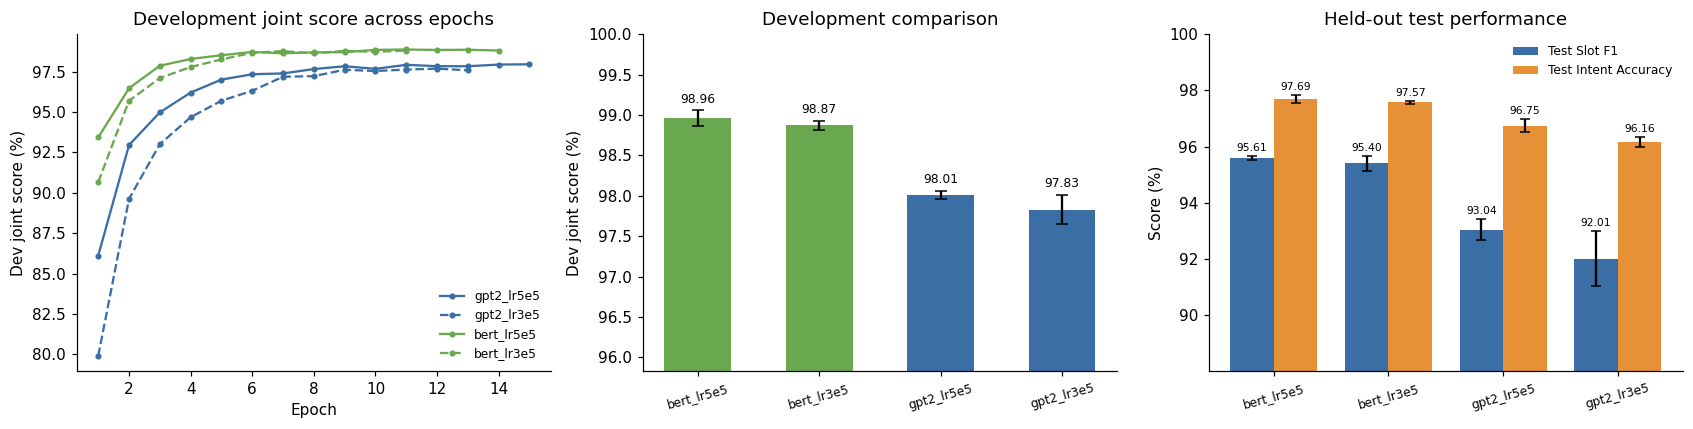

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.0))
palette = {'gpt2': '#3b6ea5', 'bert': '#6aa84f'}

# (a) dev joint score per epoch, averaged over the three seeds
for r in results:
    n = min(len(h) for h in r['hists'])
    mean = np.mean([h[:n] for h in r['hists']], axis=0) * 100
    axes[0].plot(np.arange(1, n + 1), mean, marker='o', ms=3,
                 color=palette[r['kind']],
                 ls='-' if str(r['lr']) == '5e-05' else '--', label=r['name'])
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Dev joint score (%)')
axes[0].set_title('Development joint score across epochs')
axes[0].legend(frameon=False, fontsize=8)

# (b) dev joint with seed spread
order = sorted(results, key=lambda r: -r['dev_joint'])
x = np.arange(len(order))
b = axes[1].bar(x, [r['dev_joint'] for r in order],
                yerr=[r['dev_joint_std'] for r in order], capsize=4,
                color=[palette[r['kind']] for r in order], width=0.55)
axes[1].bar_label(b, fmt='%.2f', fontsize=8, padding=3)
axes[1].set_xticks(x, [r['name'] for r in order], rotation=15, fontsize=8)
axes[1].set_ylabel('Dev joint score (%)'); axes[1].set_title('Development comparison')
axes[1].set_ylim(min(r['dev_joint'] for r in order) - 2, 100)

# (c) held-out test performance
w = 0.38
b1 = axes[2].bar(x - w / 2, [r['test_f1'] for r in order], w,
                 yerr=[r['test_f1_std'] for r in order], capsize=3,
                 label='Test Slot F1', color='#3b6ea5')
b2 = axes[2].bar(x + w / 2, [r['test_acc'] for r in order], w,
                 yerr=[r['test_acc_std'] for r in order], capsize=3,
                 label='Test Intent Accuracy', color='#e69138')
for bars in (b1, b2):
    axes[2].bar_label(bars, fmt='%.2f', fontsize=7, padding=2)
axes[2].set_xticks(x, [r['name'] for r in order], rotation=15, fontsize=8)
axes[2].set_ylabel('Score (%)'); axes[2].set_title('Held-out test performance')
axes[2].set_ylim(min(r['test_f1'] for r in order) - 4, 100)
axes[2].legend(frameon=False, fontsize=8)

for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

### What the numbers say

In [11]:
from IPython.display import Markdown

gpt = max([r for r in results if r['kind'] == 'gpt2'], key=lambda r: r['dev_joint'])
brt = max([r for r in results if r['kind'] == 'bert'], key=lambda r: r['dev_joint'])

display(Markdown(f"""
On their own best settings BERT reaches **{brt['test_f1']:.2f} ± {brt['test_f1_std']:.2f}**
test slot F1 against GPT2's **{gpt['test_f1']:.2f} ± {gpt['test_f1_std']:.2f}**, a gap of
{brt['test_f1'] - gpt['test_f1']:.2f} points. On intent they are much closer —
{brt['test_acc']:.2f} versus {gpt['test_acc']:.2f}, only
{brt['test_acc'] - gpt['test_acc']:.2f} apart.

That pattern is the difference between the two architectures showing up in the results.
Slot filling is a decision about each individual token, and BERT gets to look at the words
on both sides before making it. GPT2 only ever sees what came before, so when it tags a
word it has no idea what follows — and in ATIS what follows often settles the label
("boston" is a departure or an arrival depending on whether "from" or "to" preceded it,
but plenty of cases only resolve later in the sentence). Intent is one decision about the
whole utterance, and by the time GPT2 reaches its last token it has read everything, so
almost nothing is lost there.

The learning rate mattered less than the choice of model. Moving from 3e-5 to 5e-5 changed
BERT's slot F1 by {brt['test_f1'] - min(r['test_f1'] for r in results if r['kind'] == 'bert'):.2f}
points, well under the {brt['test_f1'] - gpt['test_f1']:.2f} point gap between the two
backbones.

Both models also converged quickly — best epochs land around
{min(r['best_epoch_mean'] for r in results):.1f}–{max(r['best_epoch_mean'] for r in results):.1f},
where the from-scratch model in Part 2.A needed tens of epochs. The pretrained weights
already encode most of what the task needs; training mainly has to wire the two heads onto
representations that are largely there.
"""))


On their own best settings BERT reaches **95.61 ± 0.07**
test slot F1 against GPT2's **93.04 ± 0.38**, a gap of
2.57 points. On intent they are much closer —
97.69 versus 96.75, only
0.94 apart.

That pattern is the difference between the two architectures showing up in the results.
Slot filling is a decision about each individual token, and BERT gets to look at the words
on both sides before making it. GPT2 only ever sees what came before, so when it tags a
word it has no idea what follows — and in ATIS what follows often settles the label
("boston" is a departure or an arrival depending on whether "from" or "to" preceded it,
but plenty of cases only resolve later in the sentence). Intent is one decision about the
whole utterance, and by the time GPT2 reaches its last token it has read everything, so
almost nothing is lost there.

The learning rate mattered less than the choice of model. Moving from 3e-5 to 5e-5 changed
BERT's slot F1 by 0.21
points, well under the 2.57 point gap between the two
backbones.

Both models also converged quickly — best epochs land around
7.7–13.3,
where the from-scratch model in Part 2.A needed tens of epochs. The pretrained weights
already encode most of what the task needs; training mainly has to wire the two heads onto
representations that are largely there.
